# Dimension-wise Class Activation Map (dCAM)

In [79]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

/tmp/ipykernel_18010/82325636.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from random import randint
import os
import sys
from torch.utils import data
import torch
from torch.autograd import Variable
from sklearn.model_selection import train_test_split

In [81]:
sys.path.insert(0, '../src/models')
from CNN_models import ConvNet2D, ModelCNN, TSDataset
sys.path.insert(0, '../src/explanation')
from DCAM import DCAM

# Functions

In [82]:
def gen_cube(instance):
    """
        Generate a cube structure from a given multivariate instance.

        Parameters
        ----------
        instance : list
            List of sequences (e.g., multivariate time series), where each element corresponds to a channel.

        Returns
        -------
        list
            A cube structure (list of lists) where each sublist is a cyclic permutation of the input instance.
        """
    result = []
    for i in range(len(instance)):
        result.append([instance[(i+j)%len(instance)] for j in range(len(instance))])
    return result

def get_md5sum_arr(*arrs):
    """
    Compute the MD5 checksum for each input NumPy array.
    Parameters
    ----------
    *arrs : array-like
        One or more NumPy arrays for which to compute the MD5 checksum.
    Returns
    -------
    list of str
        A list containing the hexadecimal MD5 checksum string for each input array.
    Notes
    -----
    The function ensures that each array is stored in contiguous memory before computing the checksum,
    to guarantee consistent results regardless of the original memory layout.
    """
    import hashlib
    out = []
    for arr in arrs:
        arr_c = np.ascontiguousarray(arr)  # ensure memory layout consistency
        out.append(hashlib.md5(arr_c.tobytes()).hexdigest())
    return out

def _shape_data(X: list) -> np.ndarray:
    """Convert list of lists to a 3D NumPy array."""
    def _gen_cube(instance: list) -> list:
        """
            Generate a cube structure from a given multivariate instance.
            SEE: https://github.com/boniolp/dCAM/blob/2072b07c3c645ba980c3d31548f1b90c2126adb7/experiments/classification/scripts/script_exp_dataset.py#L42-L46

            Parameters
            ----------
            instance : list
                List of sequences (e.g., multivariate time series), where each element corresponds to a channel.

            Returns
            -------
            list
                A cube structure (list of lists) where each sublist is a cyclic permutation of the input instance.
            """
        result = []
        for i in range(len(instance)):
            result.append([instance[(i+j)%len(instance)] for j in range(len(instance))])
        return result
    
    # flatten the instances (considering amplitude and phase if specified) # NOTE: Using in dB scale
    downsample_factor = 2
    X_flatten = []
    for x_instance in X:
        sigs = []
        for sig_pair in x_instance:
            sigs.extend([10*np.log10(np.square(sig_pair[0][::downsample_factor]))])
        X_flatten.append(sigs)
    X = np.array([_gen_cube(x) for x in X_flatten])
    return X

### Load Dataset

In [83]:
# Load scintillation signals stored as a pickle tuple (class_weak, class_strong)
data_path = Path('scint_signals5.pkl')
with data_path.open('rb') as f:
    X, y = pickle.load(f)

print("X and y MD5 checksums:")
for md5sum in get_md5sum_arr(X, y.codes):
    print(f"MD5 checksum: {md5sum}")

X and y MD5 checksums:
MD5 checksum: 191ad24c066c31b7f16fded2a7dacc6d
MD5 checksum: 9646e0bfa16685714d55070ef1086003


### GPU

In [84]:
def require_cuda():
    # Do not change CUDA_VISIBLE_DEVICES after kernel start.
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA not available in this process. Check driver, nvidia-smi, and CUDA_VISIBLE_DEVICES.")
    try:
        _ = torch.empty(1, device="cuda")
        torch.cuda.synchronize()
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    except Exception as e:
        raise RuntimeError(f"CUDA detected but unusable: {e}. Likely stale processes or driver issue.")

device = require_cuda()
batch_size = 32
print(f"Using device: {device}")


Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Using device: cuda


In [ ]:
which_way = "his"
if which_way == "me":
    X_corrupted = _shape_data(X)
    for md5sum in get_md5sum_arr(X_corrupted, y.codes): # CAVEAT: check point
        print(f"MD5 checksum: {md5sum}")

    # dataset metadata
    n_class = 2
    n_instance = X_corrupted.shape[0] // 2
    n_chan = X_corrupted.shape[1]
    n_sample = X_corrupted.shape[3]

    print(f'Loaded {n_instance} scintillation instances per class from {data_path.name}.')
    print(f'Each sample contains {n_chan} channels with {n_sample} samples.')
    print(f'Total dataset size: {2 * n_instance} instances.')

    # Shuffle and split
    all_class_trn, all_class_tst, label_trn, label_tst = train_test_split(X_corrupted, y, shuffle=True, random_state=1)

    for md5sum in get_md5sum_arr(all_class_trn, all_class_tst, label_trn.codes, label_tst.codes): # CAVEAT: check point
            print(f"MD5 checksum: {md5sum}")

    x = all_class_trn
    dataset_mat = TSDataset(x,label_trn.codes)
    dataloader_cl1_trn = data.DataLoader(dataset_mat, batch_size=batch_size, shuffle=True)

    x = all_class_tst
    dataset_mat_test = TSDataset(x,label_tst.codes)
    dataloader_cl1_tst = data.DataLoader(dataset_mat_test, batch_size=1, shuffle=True)

elif which_way == "his":
    train_size, test_size = 48, 17
    X_weak = [x for i, x in enumerate(X) if y[i] == 'weak']
    X_w = [[x[0] for x in X_channel] for X_channel in X_weak]
    X_strong = [x for i, x in enumerate(X) if y[i] == 'strong']
    X_s = [[x[0] for x in X_channel] for X_channel in X_strong]

    # downsample and convert to dB scale
    downsample_factor = 2
    X_w = [[10*np.log10(np.square(sig[::downsample_factor])) for sig in instance] for instance in X_w]
    X_s = [[10*np.log10(np.square(sig[::downsample_factor])) for sig in instance] for instance in X_s]
    
    # dataset metadata
    n_class = 2
    train_test_r = 0.75
    n_instance = min(len(X_w), len(X_s))
    n_chan = len(X_w[0])
    n_sample = len(X_w[0][0])
    train_size = int(n_instance * train_test_r)
    test_size = n_instance - train_size

    for md5sum, name in zip(get_md5sum_arr(X_w, X_s), ("X_w", "X_s")):
        print(f"MD5 {name}: {md5sum}")

    all_class_trn = X_w[:train_size] + X_s[:train_size]
    all_class_tst = X_w[train_size:train_size + test_size] + X_s[train_size:train_size + test_size]

    all_class_trn = np.array([gen_cube(acl) for acl in all_class_trn])
    all_class_tst = np.array([gen_cube(acl) for acl in all_class_tst])

    label_trn = np.array([0] * train_size + [1] * train_size)
    label_tst = np.array([0] * test_size + [1] * test_size)

    # CAVEAT: for some reason `train_test_split` makes the results bad. Uncomment to check. This overwrites the above splitting (his way).
    # all_class = X_w + X_s
    # all_class = np.array(all_class)
    # label = np.array([0] * len(X_w) + [1] * len(X_s))
    # all_class_trn, all_class_tst, label_trn, label_tst = train_test_split(all_class, label, shuffle=False, random_state=1)
    # all_class_trn = np.array([gen_cube(acl) for acl in all_class_trn])
    # all_class_tst = np.array([gen_cube(acl) for acl in all_class_tst])
    
    # for md5sum, name in zip(get_md5sum_arr(all_class_trn, all_class_tst, label_trn, label_tst), ("all_class_trn", "all_class_tst", "label_trn", "label_tst")): # CAVEAT: check point
    #     print(f"MD5 {name}: {md5sum}")

    x = all_class_trn
    dataset_mat = TSDataset(x,label_trn)
    dataloader_cl1_trn = data.DataLoader(dataset_mat, batch_size=batch_size, shuffle=True)

    x = all_class_tst
    dataset_mat_test = TSDataset(x,label_tst)
    dataloader_cl1_tst = data.DataLoader(dataset_mat_test, batch_size=1, shuffle=True)

MD5 X_w: c6e4e6c49cd192ea7bc09604c8b5c692
MD5 X_s: 8a1fa4fa2d27f857d64494f12b706b8f


In [86]:
all_class_trn.shape

(96, 25, 25, 751)

# Training the model

Note that the usage of Batchnorm layer is not appropriate to all use cases. By expirience, this layer cause an instablility and a lower convergence is some of the use cases tested. It seems that this layer make some pertubation fail to be classified.

### Training the model

In [87]:
from torchsummary import summary

#dCNN
modelarch = ConvNet2D(n_sample,n_chan,n_chan,n_class).to(device)

model = ModelCNN(modelarch,device)

summary(model.model.to(device),input_size=(n_chan,n_chan,n_sample), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 128, 25, 751]           9,728
       BatchNorm2d-2         [-1, 128, 25, 751]             256
              ReLU-3         [-1, 128, 25, 751]               0
            Conv2d-4         [-1, 128, 25, 751]          49,280
       BatchNorm2d-5         [-1, 128, 25, 751]             256
              ReLU-6         [-1, 128, 25, 751]               0
            Conv2d-7         [-1, 256, 25, 751]          98,560
       BatchNorm2d-8         [-1, 256, 25, 751]             512
              ReLU-9         [-1, 256, 25, 751]               0
           Conv2d-10         [-1, 256, 25, 751]         196,864
      BatchNorm2d-11         [-1, 256, 25, 751]             512
             ReLU-12         [-1, 256, 25, 751]               0
           Conv2d-13         [-1, 256, 25, 751]         196,864
             ReLU-14         [-1, 256, 

In [88]:
print("all_class_trn shape:", all_class_trn.shape)
print("all_class_tst shape:", all_class_tst.shape)
print("n_sample (inferred):", all_class_trn.shape[-1])
# show one sample shape
print("example sample shape:", all_class_trn[0].shape)

all_class_trn shape: (96, 25, 25, 751)
all_class_tst shape: (34, 25, 25, 751)
n_sample (inferred): 751
example sample shape: (25, 25, 751)


In [89]:
model.train(num_epochs=70, dataloader_cl1=dataloader_cl1_trn, dataloader_cl1_test=dataloader_cl1_tst)

Epoch [1/70], Loss Train: 0.6774,Loss Test: 0.6816, Accuracy Train: 93.75%, Accuracy Test: 55.88%
Epoch [11/70], Loss Train: 0.4796,Loss Test: 0.4835, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [21/70], Loss Train: 0.3375,Loss Test: 0.3126, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [31/70], Loss Train: 0.2424,Loss Test: 0.2180, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [41/70], Loss Train: 0.1713,Loss Test: 0.1518, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [51/70], Loss Train: 0.1214,Loss Test: 0.1085, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [61/70], Loss Train: 0.0894,Loss Test: 0.0787, Accuracy Train: 100.00%, Accuracy Test: 100.00%


### Train and test loss (Binary Cross Entropy) versus Epoch  

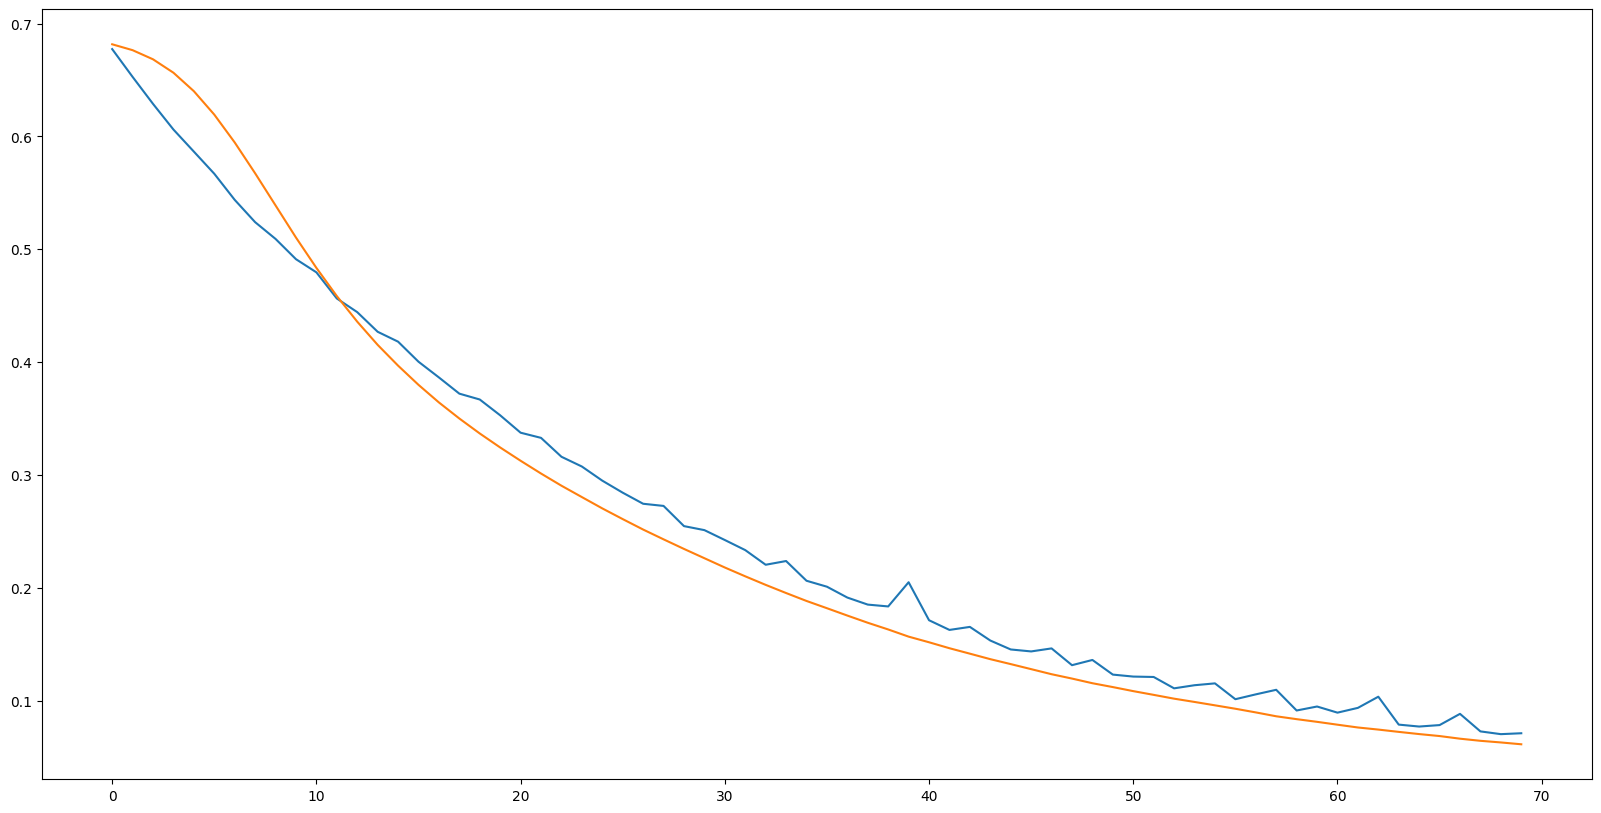

In [90]:
plt.figure(figsize=(20,10))
plt.plot(model.loss_train_history)
plt.plot(model.loss_test_history)

# d-CAM Class Activation Map


In [91]:
model = torch.load("model", map_location=device, weights_only=False).to(device)
model = model.eval()

instance_idx = 0
instance = np.array(X_s[instance_idx])
label_instance = 1

# dCNN
last_conv_layer = model._modules['layer3']
fc_layer_name = model._modules['fc1']

# dResNet
#last_conv_layer = model.model._modules['layers'][2]
#fc_layer_name = model.model._modules['final']

#InceptionTime
#last_conv_layer = model.model._modules['blocks'][2]
#fc_layer_name = model.model._modules['linear']



DCAM_m = DCAM(model,device,last_conv_layer=last_conv_layer,fc_layer_name=fc_layer_name)
dcam, permutation_success = DCAM_m.run(
    instance=[i for i in instance],
    nb_permutation=200,
    label_instance=label_instance)

  0%|          | 0/200 [00:00<?, ?it/s]/home/tapyu/git/dCAM/examples/../src/explanation/DCAM.py:113: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pred_probabilities = F.softmax(prediction).data.squeeze()
100%|██████████| 200/200 [00:10<00:00, 19.64it/s]


# Plot for strong

/tmp/ipykernel_18010/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_18010/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_18010/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_18010/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_18010/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"D

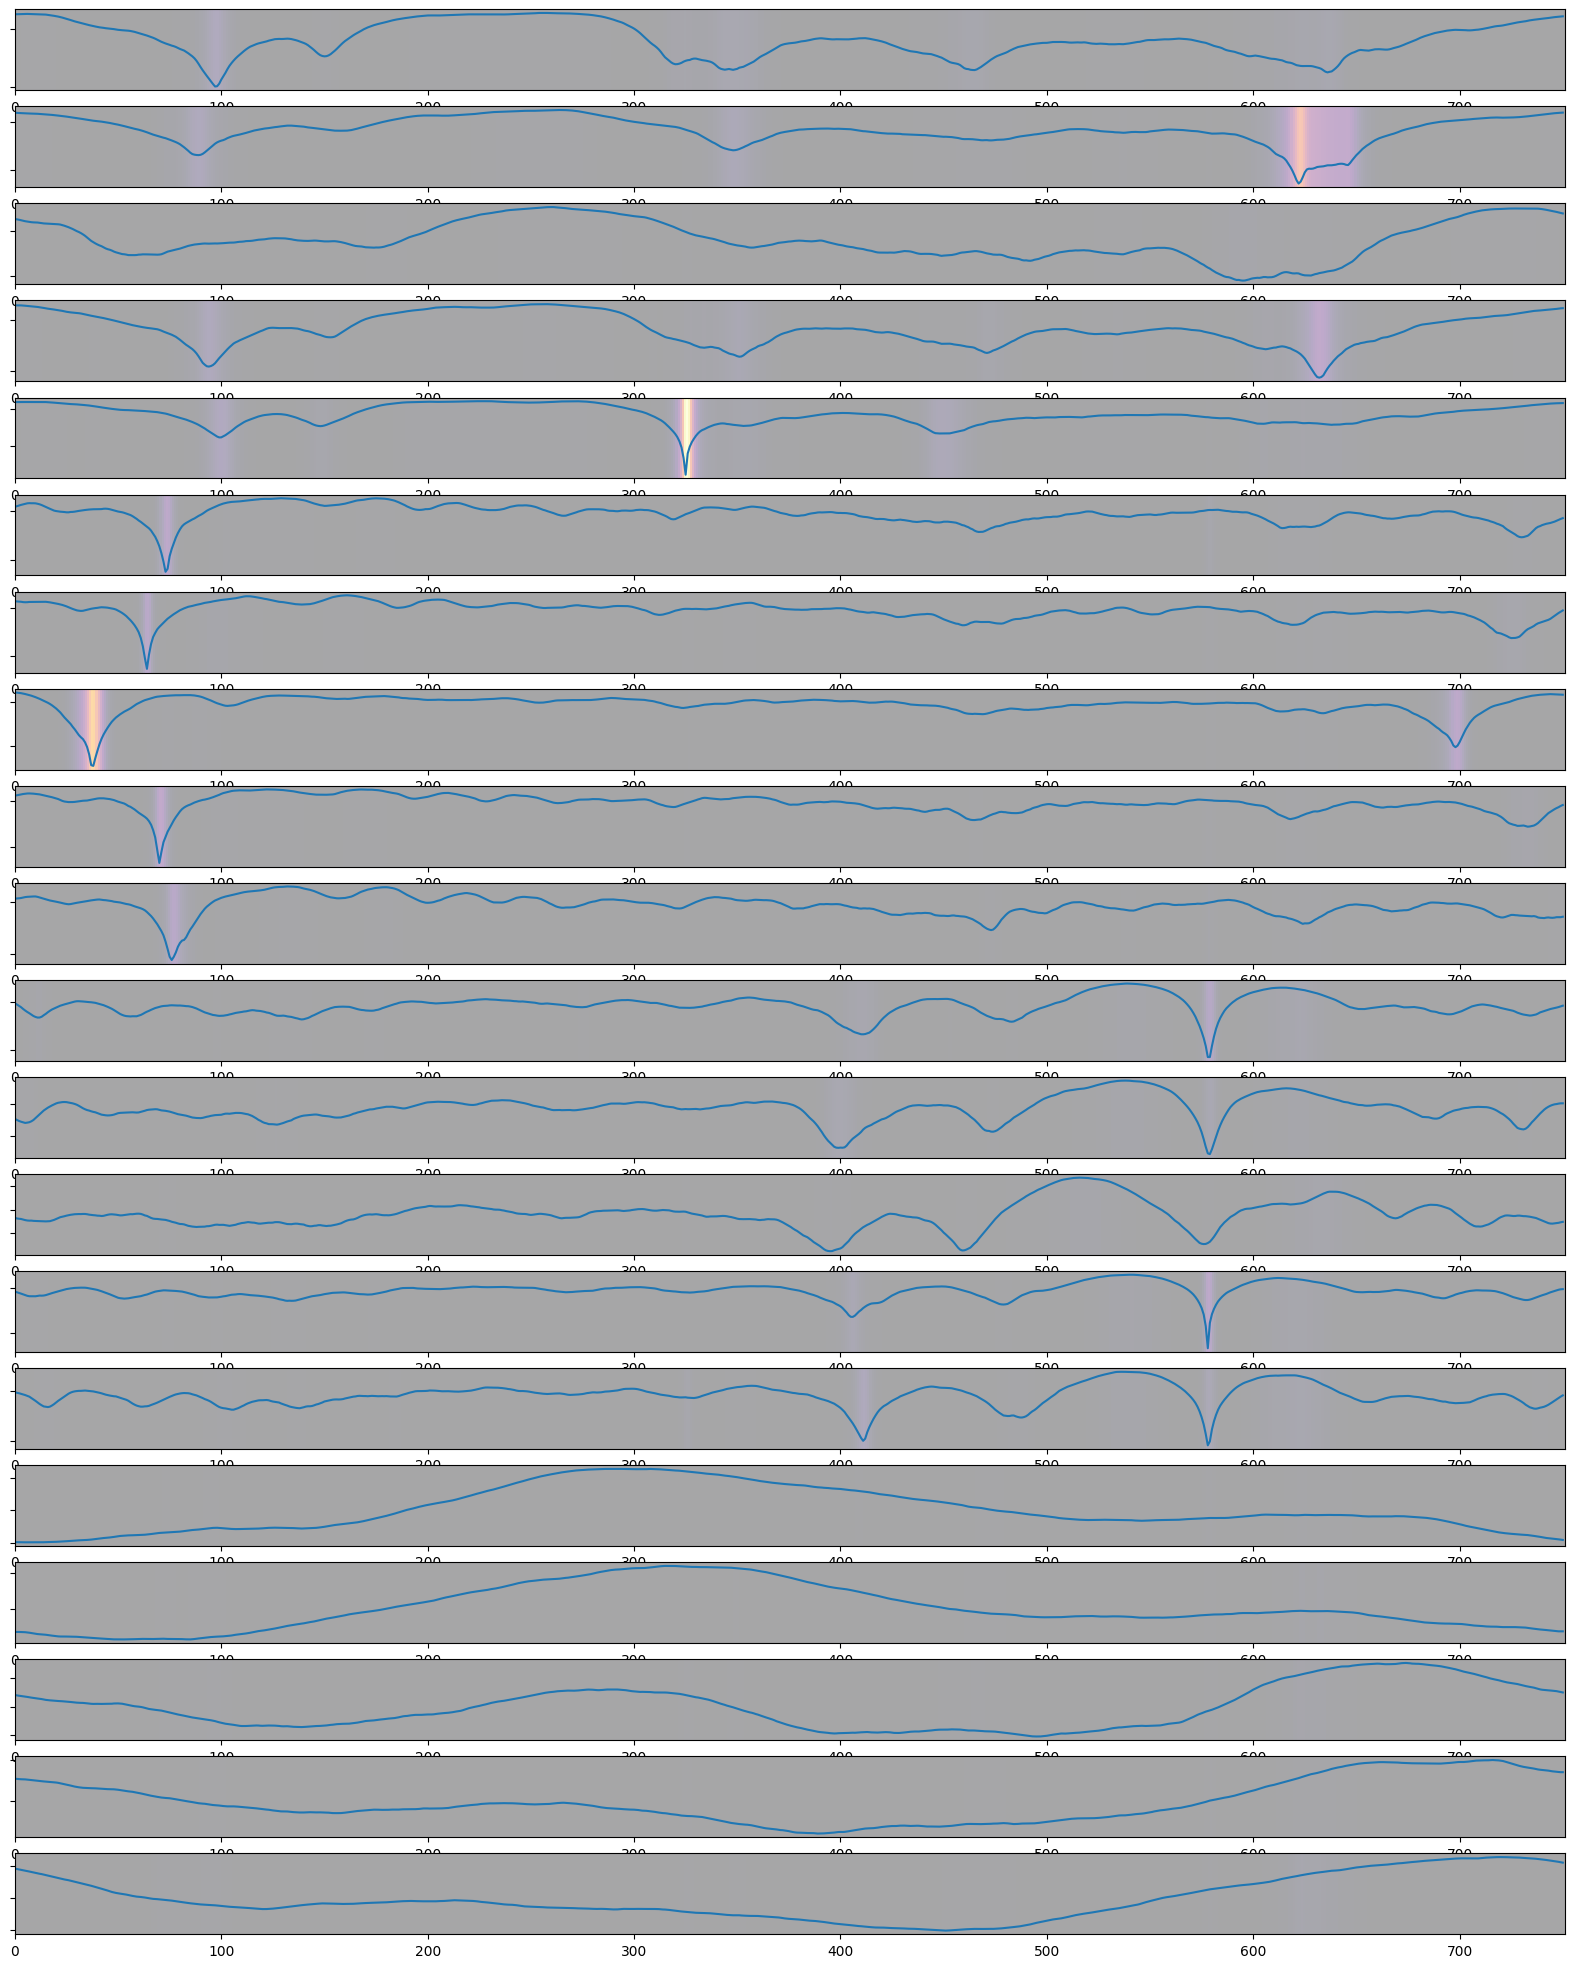

In [92]:
K = 20
dcam_min = np.min(dcam)
dcam_max = np.max(dcam)
dcam_range = dcam_max - dcam_min

dcam_norm = (dcam - dcam_min) / dcam_range
vmin, vmax = float(dcam_norm.min()), float(dcam_norm.max())

plt.figure(figsize=(20, 25))
for i in range(K):
    ax = plt.subplot(K, 1, i + 1)
    ax.plot(instance[i], color="tab:blue")
    ax.set_xlim(0, len(instance[i]))
    ax.set_yticklabels([f"Dim {i}"])

    ymin, ymax = ax.get_ylim()
    ax.imshow(
        dcam_norm[i][np.newaxis, :],
        extent=[0, len(dcam[i]), ymin, ymax],
        aspect="auto",
        cmap="inferno",
        alpha=0.35,
        vmin=vmin, vmax=vmax, # enforce global scaling
        interpolation="none",
    )
    ax.set_ylim(ymin, ymax)
